In [93]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
class MASlopeBacktester:
    def __init__(self, symbol, MA, start, end):
        self.symbol = symbol
        self.MA = MA
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["MA"] = data.Close.rolling(self.MA).mean()
        data["MA_slope"] = data["MA"].diff() / 1  # Slope: difference in MA over 1 period
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        data["position"] = np.where(data["MA_slope"] > 0, 1, 0)  # Long if slope > 0, short if slope < 0
        data["strategy"] = data["returns"] * data.position.shift(1)  # Shift position to avoid look-ahead bias
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)  # Buy-and-hold cumulative returns
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)  # Strategy cumulative returns
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        self.results = data
        ret = np.exp(data["strategy"].sum())
        std = data["strategy"].std() * np.sqrt(252)  # Annualized standard deviation
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = f"{self.symbol} | MA={self.MA} Slope Strategy"
            plt.style.use("seaborn-v0_8")
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.legend(["Buy & Hold", "MA Slope Strategy"], loc="upper left", fontsize=12)
            plt.xlabel("Date", fontsize=12)
            plt.ylabel("Cumulative Returns", fontsize=12)
            plt.show()
    
    def plot_moving_average(self):
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        data[["Close", "MA"]].plot(figsize=(12, 8), fontsize=12)
        plt.legend(["Close Price", f"MA{self.MA}"], loc="upper left", fontsize=12)
        plt.title(f"{self.symbol} Price with MA{self.MA}", fontsize=15)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.show()

    def plot_ma_with_position(self, year=None):
        if self.results is None:
            print("Run the test please")
        else:
            data = self.results.copy()
            plt.style.use("seaborn-v0_8")
            if year:
                data = data.loc[str(year)]
            fig, ax1 = plt.subplots(figsize=(12, 8))
            ax1.plot(data.index, data["Close"], label="Close Price", color="blue")
            ax1.plot(data.index, data["MA"], label=f"MA{self.MA}", color="orange")
            ax1.set_xlabel("Date", fontsize=12)
            ax1.set_ylabel("Price", fontsize=12, color="blue")
            ax1.tick_params(axis="y", labelcolor="blue")
            ax1.legend(loc="upper left", fontsize=12)
            ax2 = ax1.twinx()
            ax2.plot(data.index, data["position"], label="Position", color="green", linestyle="--")
            ax2.set_ylabel("Position", fontsize=12, color="green")
            ax2.tick_params(axis="y", labelcolor="green")
            ax2.legend(loc="upper right", fontsize=12)
            plt.title(f"{self.symbol} - MA{self.MA} with Position", fontsize=15)
            plt.show()

In [109]:
tester= MASlopeBacktester("NVDA",20,"2020-06-23","2025-06-23")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_26009/2693569499.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [110]:
tester.test_results()

(4.391771, -9.434039)

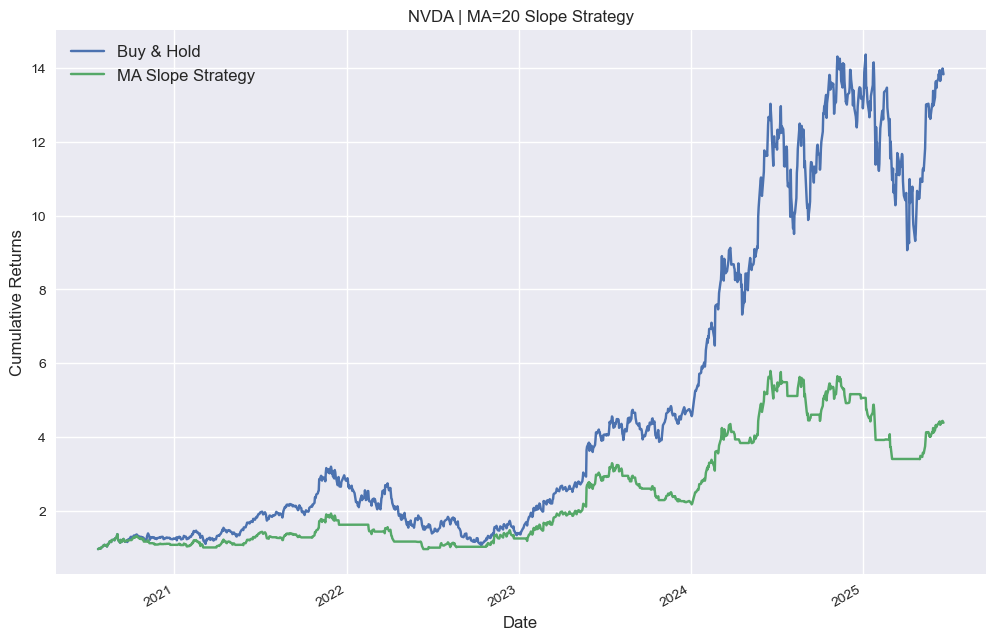

In [111]:
tester.plot_results()

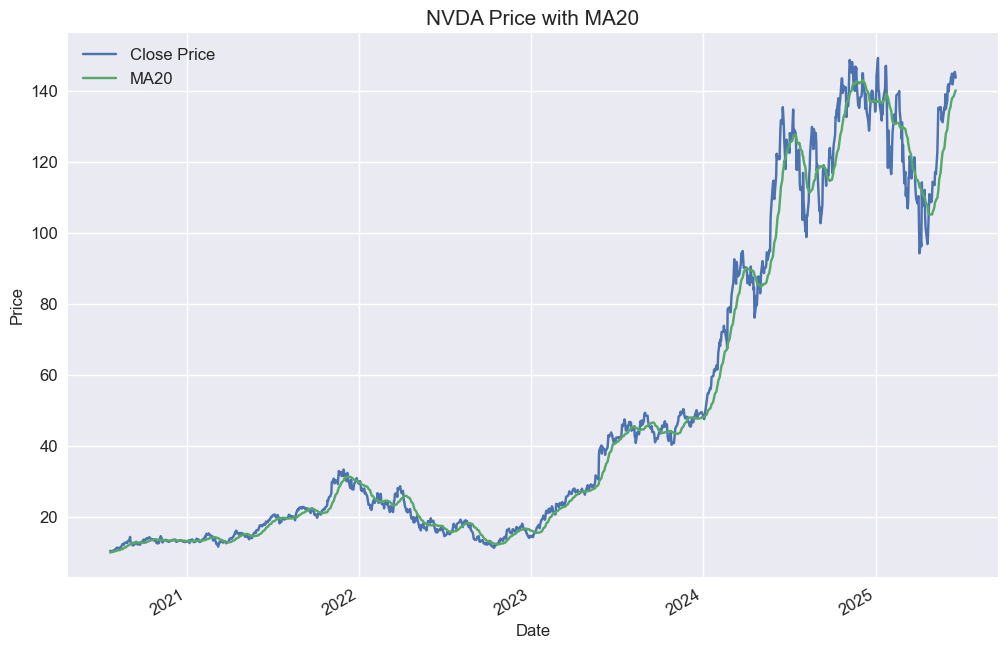

In [106]:
tester.plot_moving_average()

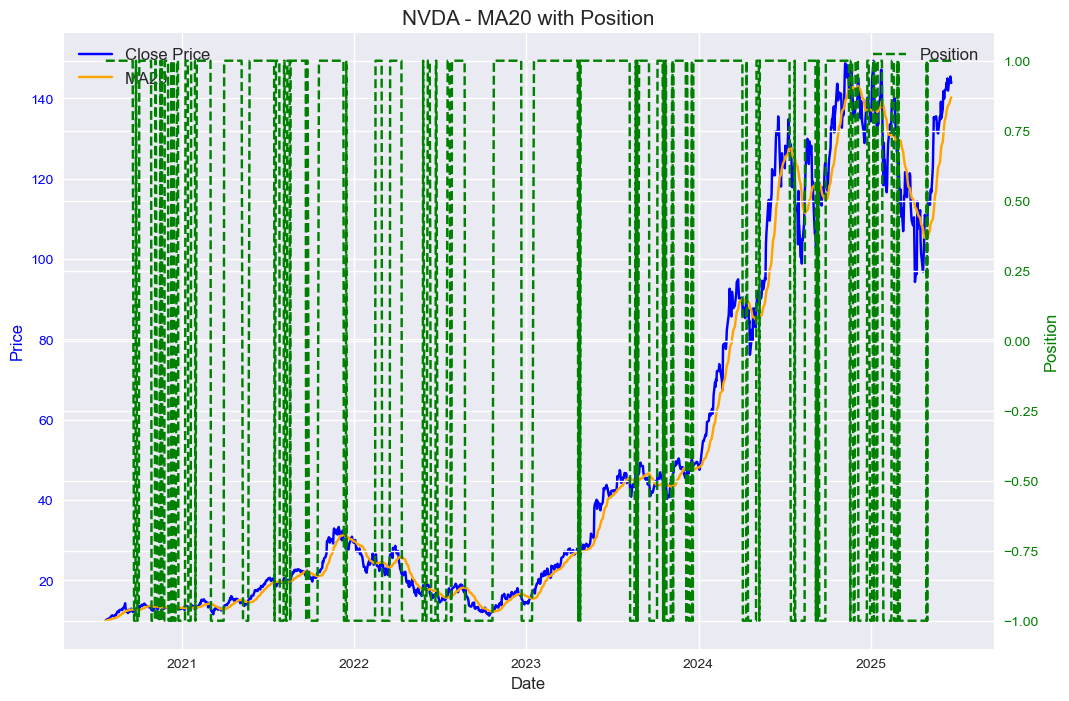

In [107]:
tester.plot_ma_with_position()